## Import all the necessary config files

In [1]:
from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import re
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [2]:
# model name to be included in file names later with the output_title function, creating an iteration subscript, e.g. Run_001
title = 'Run'

## Run the coral model

In [3]:
print(growth_rate_df)

   CoralType  GrowthRate_cm_per_year
0  Branching                    3.70
1    Foliose                    1.10
2      Other                    0.25


In [4]:
# This runs the model once for the number of years selected in the user input files
run_coral_model(PSD_T0, MaxYear)

,Year,Branching_Area (%),Foliose_Area (%),Other_Area (%),total_coral_cover (%)
0,0,5.700000,2.600000,20.300000,28.600000
1,1,5.815352,2.628944,20.145208,28.589504
2,2,1.538660,0.924737,10.342249,12.805647
3,3,2.381108,0.950045,10.373719,13.704873
4,4,3.640545,0.992803,10.643182,15.276530
5,5,5.323714,1.036143,10.711463,17.071320
6,6,7.612214,1.072244,10.890550,19.575008
7,7,10.549545,1.112049,11.210837,22.872431
8,8,14.110191,1.147373,11.364595,26.622159
9,9,18.291503,1.179733,11.361644,30.832880


## Plot the change in total coral cover over the years

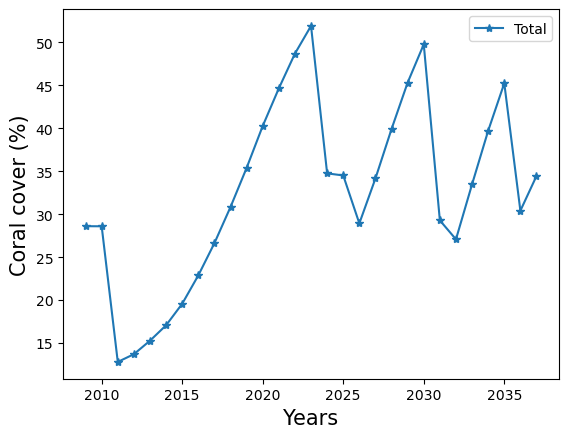

In [5]:
# Build actual years based on row count
n = len(opts.yearly_total_coral_cover_df)
actual_years = range(year_start, year_start + n)

# Plot with actual years as x-values
plt.plot(actual_years,
         opts.yearly_total_coral_cover_df['total_coral_cover (%)'],
         '-*',
         label='Total')

plt.xlabel('Years', fontsize=15)
plt.ylabel('Coral cover (%)', fontsize=15)
plt.legend()

# Make x-axis labels integers only
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## The benthic cover over the years in percentage

In [6]:
opts.yearly_benthic_cover_df

,Year,total_benthic_cover (%),available_substrate (%),hard_substrate (%),dead_coral (%),CCA (%),turfing_algae (%),macro_algae (%),rubble (%),sediment (%),total_cc,unavailable_sub,tot
0,0,71.400000,54.600000,0.0,0.000000,10.500000,44.100000,9.400000,1.000000,6.400000,28.600000,16.800000,100.000000
1,1,71.410496,54.749385,0.0,0.293795,10.504086,43.972809,9.403658,0.833658,6.402490,28.589504,16.633333,99.972222
2,2,87.194353,63.409756,0.0,6.501311,10.535182,46.560981,9.431497,7.743937,6.421445,12.805647,23.527228,99.742631
3,3,86.295127,63.773795,0.0,7.485341,10.561509,45.886312,9.455065,6.469408,6.437491,13.704873,22.306222,99.784891
4,4,84.723470,63.260034,0.0,8.180799,10.583959,44.629742,9.475163,5.402632,6.451175,15.276530,21.283730,99.820294
5,5,82.928680,62.350075,0.0,8.668824,10.603147,43.191142,9.492341,4.510356,6.462870,17.071320,20.428532,99.849927
6,6,80.424992,60.585863,0.0,8.890600,10.619690,41.170102,9.507151,3.764494,6.472954,19.575008,19.713841,99.874712
7,7,77.127569,57.905815,0.0,8.839821,10.634108,38.510501,9.520059,3.141338,6.481742,22.872431,19.117184,99.895431
8,8,73.377841,54.670999,0.0,8.586293,10.646769,35.503029,9.531393,2.620898,6.489459,26.622159,18.619582,99.912741
9,9,69.167120,50.889383,0.0,8.141223,10.657987,32.143793,9.541436,2.186383,6.496297,30.832880,18.204934,99.927197


## Plot the benthic cover over the years for turfing algae, dead coral, rubble, macro algae and total coral cover in percentage

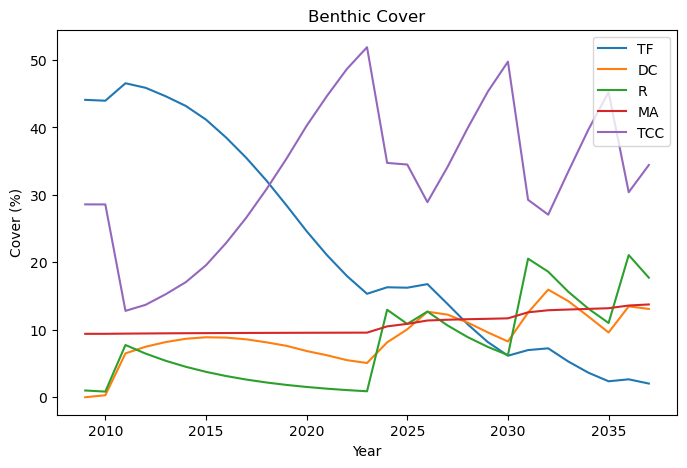

In [7]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## Export the data frames to excel

In [8]:
# This function exports data frames to Excel 

export_to_excel(opts.yearly_population_df_list,'yearly_population')
export_to_excel(opts.yearly_surface_area_df_list,'yearly_surface_area')
export_to_excel(opts.yearly_total_coral_cover_df,'yearly_total_coral_cover')
export_to_excel(opts.yearly_benthic_cover_df,'yearly_benthic_cover')

## Plots - please enter the years (within model range) for each plot

(2, 6, 9, 13)


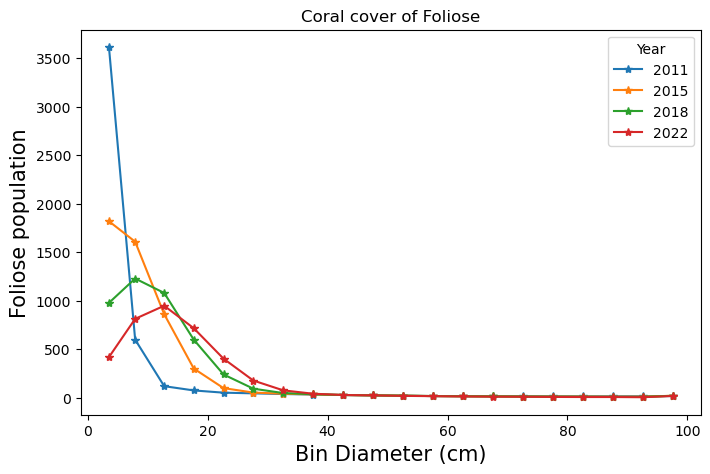

In [9]:
#Coral Cover Population

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    # Convert them to model years (indices) for the model
    model_years = tuple(year - year_start for year in Years)
    print(model_years)
    # Plot coral population change by type
    plot_coral_type_population_change('Foliose', False, *model_years)

(2, 6, 9, 13)


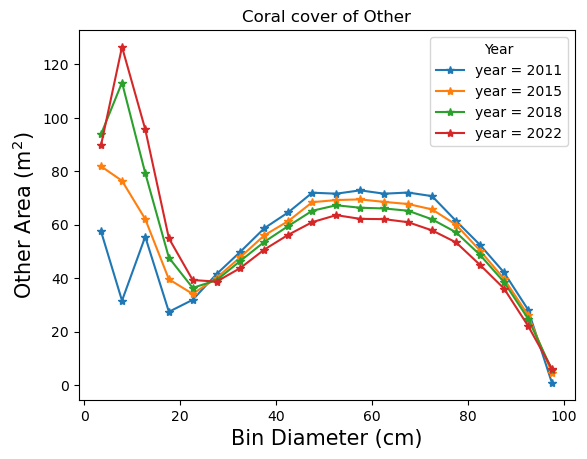

In [10]:
# This plots the Area of the coral type chosen for different input years
# Other

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    print(model_years)

    #Plot coral area change by type
    plot_coral_type_areal_change('Other', False, *model_years)

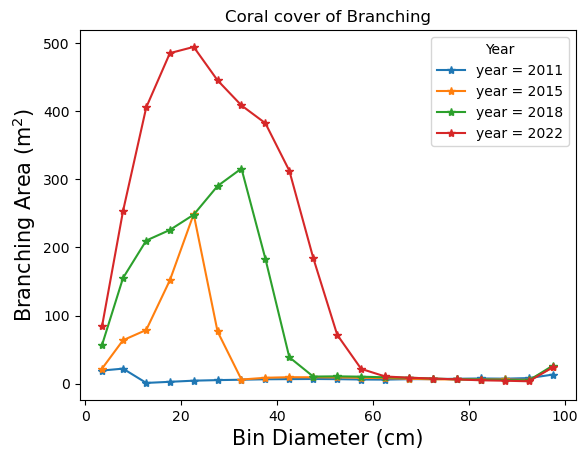

In [11]:
# This plots the Area of the coral type chosen for different input years
# Branching

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Branching', False, *model_years)

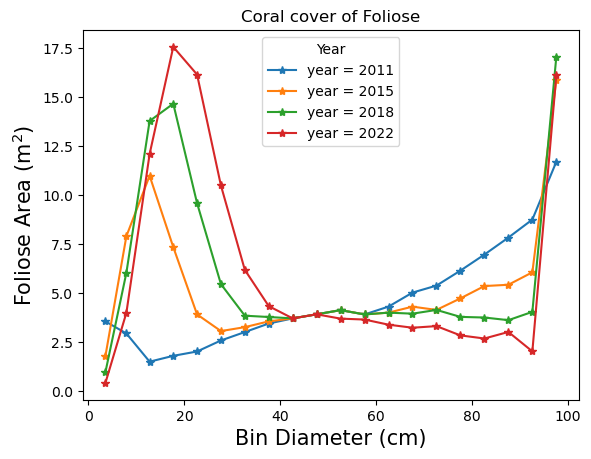

In [12]:
# This plots the Area of the coral type chosen for different input years
# Foliose

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:

    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Foliose',False, *model_years)

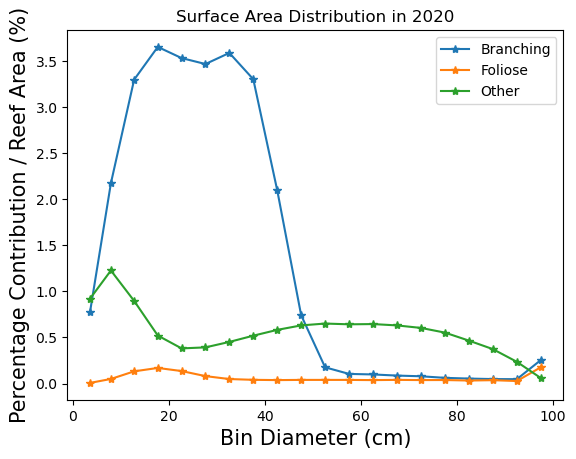

In [13]:
# Plot surface area distribution of different coral types in a given year.

Year = 2020

# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_surface_area_distribution(model_year)

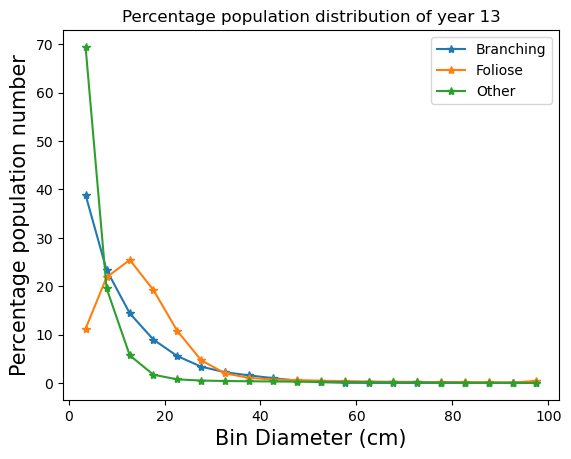

In [14]:
# This function plots the percentage population distribution of the bins in a given year. 
# plot_population_distribution_in_percentage(year)
# For example: 100*branching_population_bin_2/total_branching_population 

Year = 2022
# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_population_distribution_in_percentage(model_year)

## Rugosity

In [15]:
# This function calculates the Rugosity and returns them in a list

rugosity_list = get_rugosity_list()
export_to_excel(rugosity_list,'Rugosity')

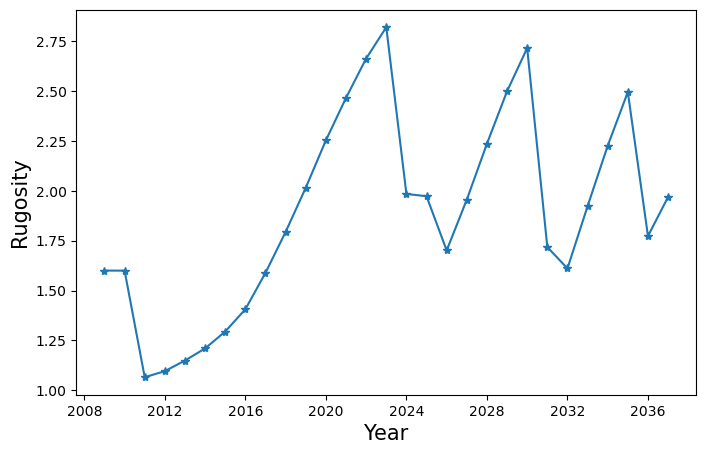

In [16]:
# This function plots the rugosity values over the years

plot_rugosity_year()

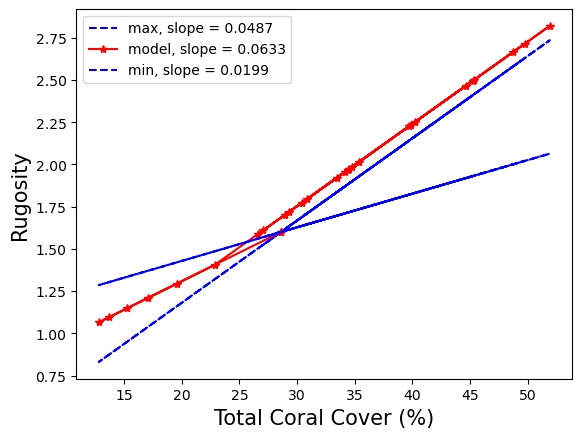

In [17]:
plot_rugosity_total_coral_cover()

## Run simulation for n number of times and plot the total coral cover

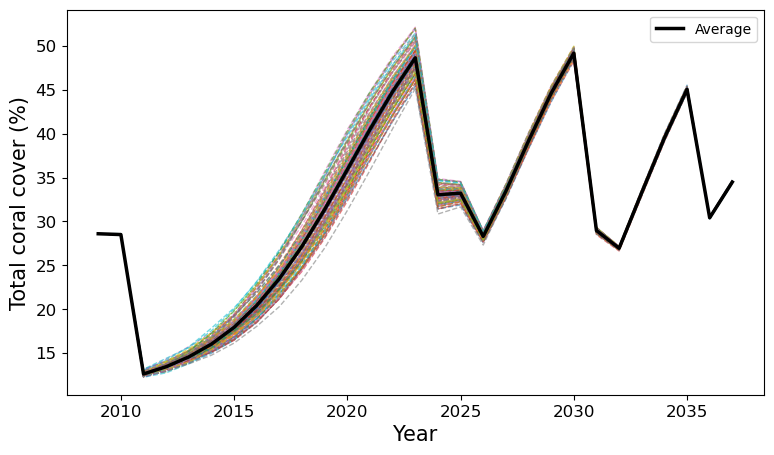

In [18]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

In [19]:
iteration_df

,year,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,iteration_9,...,iteration_92,iteration_93,iteration_94,iteration_95,iteration_96,iteration_97,iteration_98,iteration_99,iteration_100,averaged
0,0,28.600000,28.600000,28.600000,28.600000,28.600000,28.600000,28.600000,28.600000,28.600000,...,28.600000,28.600000,28.600000,28.600000,28.600000,28.600000,28.600000,28.600000,28.600000,28.600000
1,1,28.524807,28.517404,28.480284,28.493950,28.457567,28.496002,28.577586,28.510002,28.485507,...,28.552679,28.528861,28.476789,28.466952,28.580845,28.486283,28.576457,28.508313,28.513350,28.507725
2,2,12.417729,12.809251,12.630088,12.358662,12.321950,13.159620,12.593660,12.453094,12.724335,...,12.927458,12.654761,12.461777,12.857355,12.685767,12.522723,12.571453,12.536435,13.174923,12.635293
3,3,13.278582,13.509164,13.712443,12.984502,13.066466,14.077513,13.584877,13.531807,13.760011,...,13.712219,13.488176,13.359288,13.752673,13.749745,13.253937,13.606570,13.181398,14.410622,13.460775
4,4,14.300123,14.511344,15.354196,14.076916,14.231976,15.260652,14.837042,14.420279,15.145233,...,14.797365,14.408786,14.418541,14.765791,14.876446,14.367109,14.907984,13.983731,15.637886,14.578705
5,5,15.674361,15.836977,17.143167,15.386046,15.420327,16.977531,16.613505,15.870108,16.800191,...,16.637098,15.563803,16.025124,16.370949,16.381747,16.136819,16.704579,15.438492,17.553500,16.039609
6,6,17.672065,17.734388,19.437997,17.191561,17.404808,19.403039,19.095590,17.375045,18.692749,...,18.600635,17.494097,17.914974,18.123553,18.336096,18.237089,19.095563,17.044530,20.019160,17.947116
7,7,20.391273,20.431688,22.514016,19.670146,19.814846,22.705347,22.674746,19.800468,21.345482,...,21.436777,19.527233,20.897478,20.730286,20.761072,20.744433,22.106157,19.229430,23.179010,20.436779
8,8,23.919972,23.292405,26.062875,22.821057,22.641704,26.220212,26.601635,22.431483,24.468477,...,24.425933,22.292028,24.068176,23.441844,23.502641,24.220935,25.691616,21.958271,26.775463,23.499293
9,9,28.100330,26.775138,30.067579,26.499996,26.573665,30.085290,30.857189,25.827334,28.148465,...,28.240239,25.491302,27.973993,26.981058,26.889889,27.791515,30.123551,25.299168,30.804634,27.179135


In [20]:
# Real data input should be saved in the coral_data_and_custom_parameters.xlsx file
# Load the Excel file into a DataFrame

# Load Excel
real_df_raw = pd.read_excel("coral_data_and_custom_parameters.xlsx", sheet_name="Real_Cover")

# Fill + mask (returns a tuple)
real_df, created = fill_nans_columnwise(
    real_df_raw,
    year_col='Year',
    make_full_years=False,
    fallback='mean',
    return_mask=True
)

# Make Year integer-like for display
real_df['Year'] = pd.to_numeric(real_df['Year'], errors='coerce').round().astype('Int64')

value_cols = [c for c in real_df.columns if c != 'Year']

# Build red-highlight styles
styles = created.reindex_like(real_df).replace({True: 'color: red', False: ''})

# Display with exactly 2 decimals (and integer Year)
styler = (
    real_df.style
           .format({c: '{:.2f}' for c in value_cols})
           .format({'Year': '{:.0f}'})
           .apply(lambda _: styles, axis=None)
)
display(styler)


,Year,RealBranching_Area (%),RealFoliose_Area (%),RealOther_Area (%)
0,2009,5.700000,2.600000,20.300000
1,2010,6.300000,3.200000,22.300000
2,2011,1.200000,2.200000,16.300000
3,2012,1.550000,2.200000,17.400000
4,2013,1.900000,2.200000,18.500000
5,2014,3.000000,2.450000,17.400000
6,2015,4.100000,2.700000,16.300000
7,2016,6.050000,2.700000,15.200000
8,2017,8.000000,2.700000,14.100000
9,2018,10.500000,2.550000,13.500000


## Run the model through a number iterations for all parameters and export results

In [21]:
final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

#Export tables to Excel
run_id = "Run_" + make_run_id(output_folder)               # e.g. '20250808_01'
fname  = f"{run_id}_all_results.xlsx" 

# Define the graph directory path
graph_dir_t = r'output/tables'# '20250808_01_all_results.xlsx'

# fname = '20250808_01_all_results.xlsx'  # if you need this
path = os.path.join(graph_dir_t, fname)

# Create the directory if it doesn't exist
os.makedirs(graph_dir_t, exist_ok=True)

path   = os.path.join(graph_dir_t, fname)

final_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_final.xlsx"), index=False)
population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population.xlsx"), index=False)
percentage_population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population_percentage.xlsx"), index=False)
area_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_area.xlsx"), index=False)

Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            5.700000          2.600000       20.300000   
1      1            5.805427          2.596782       20.135646   
2      2            1.406649          0.888190       10.171877   
3      3            1.949137          0.896554       10.564930   
4      4            2.709602          0.925528       10.601256   
..   ...                 ...               ...             ...   
24    24           28.616012          0.369432        4.280253   
25    25           34.836404          0.387339        4.273607   
26    26           40.393361          0.402418        4.258556   
27    27           26.589684          0.298893        3.527125   
28    28           30.757360          0.309329        3.422176   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               28.600000                71.400000                54.600000   
1               28.537854        

## Create plots for coral cover, benthic cover and rugosity based on the multiple iteration runs

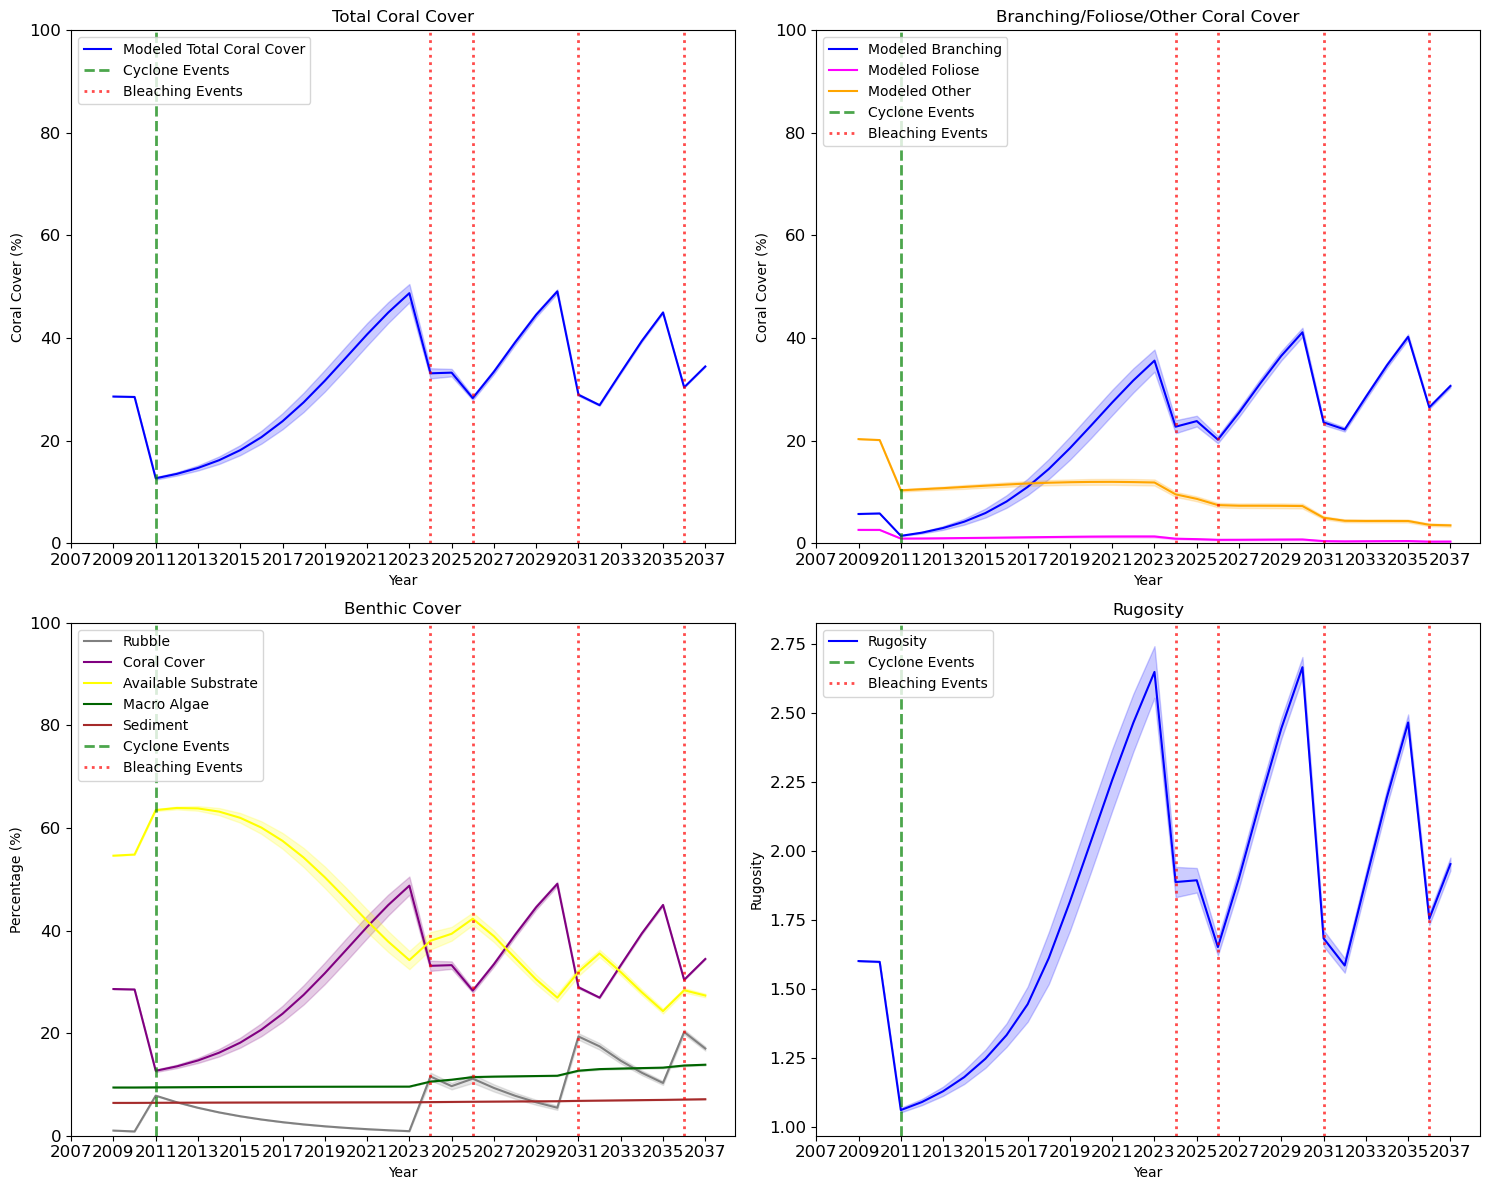

In [22]:
# Calculate the total coral cover for modelled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Define event years
# Extract years directly from dataframes
year_cyclone = [int(row['Year']) for _, row in cyclone_df.iterrows() if pd.notna(row['Year'])]
year_bleaching = [int(row['Year']) for _, row in dhw_df.iterrows() if pd.notna(row['Year'])]

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

#Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Plot Total Coral Cover
axs[0, 0].plot(actual_years, average_total, label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years, average_total - std_dev_total, average_total + std_dev_total, color='blue', alpha=0.2)
#axs[0, 0].plot(real_df['Year'], real_df['Total_Coral_Cover (%)'], label='Real Total Coral Cover', color='darkblue', linestyle='--')
#axs[0, 0].fill_between(real_df['Year'], real_df['Total_Coral_Cover (%)'] - real_total_margin, real_df['Total_Coral_Cover (%)'] + real_total_margin, color='darkblue', alpha=0.2)

# Add vertical lines for events
for i, year in enumerate(year_cyclone):
    if i == 0:  # Only add label to the first cyclone line
        axs[0, 0].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Cyclone Events')
    else:
        axs[0, 0].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2)  # No label

for i, year in enumerate(year_bleaching):
    if i == 0:  # Only add label to the first bleaching line
        axs[0, 0].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Bleaching Events')
    else:
        axs[0, 0].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2)  # No label

axs[0, 0].set_title('Total Coral Cover')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend(ncol=1)
axs[0, 0].set_ylim(0, 100)
axs[0, 0].set_xticks(actual_years)
axs[0, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(actual_years, average_branching, label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose, label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other, label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)
#axs[0, 1].plot(real_df['Year'], real_df['RealBranching_Area (%)'], label='Real Branching', color='darkblue', linestyle='--')
#axs[0, 1].fill_between(real_df['Year'], real_df['RealBranching_Area (%)'] - real_branching_margin, real_df['RealBranching_Area (%)'] + real_branching_margin, color='darkblue', alpha=0.2)
#axs[0, 1].plot(real_df['Year'], real_df['RealFoliose_Area (%)'], label='Real Foliose', color='darkmagenta', linestyle='--')
#axs[0, 1].fill_between(real_df['Year'], real_df['RealFoliose_Area (%)'] - real_foliose_margin, real_df['RealFoliose_Area (%)'] + real_foliose_margin, color='darkmagenta', alpha=0.2)
#axs[0, 1].plot(real_df['Year'], real_df['RealOther_Area (%)'], label='Real Other', color='darkorange', linestyle='--')
#axs[0, 1].fill_between(real_df['Year'], real_df['RealOther_Area (%)'] - real_other_margin, real_df['RealOther_Area (%)'] + real_other_margin, color='darkorange', alpha=0.2)

# Add vertical lines for events
for i, year in enumerate(year_cyclone):
    if i == 0:  # Only add label to the first cyclone line
        axs[0, 1].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Cyclone Events')
    else:
        axs[0, 1].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2)  # No label

for i, year in enumerate(year_bleaching):
    if i == 0:  # Only add label to the first bleaching line
        axs[0, 1].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Bleaching Events')
    else:
        axs[0, 1].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2)  # No label

axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

#years_benthic = average_rubble.index
#actual_years_benthic = [year + year_start for year in years]

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)

# Add vertical lines for events
for i, year in enumerate(year_cyclone):
    if i == 0:  # Only add label to the first cyclone line
        axs[1, 0].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Cyclone Events')
    else:
        axs[1, 0].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2)  # No label

for i, year in enumerate(year_bleaching):
    if i == 0:  # Only add label to the first bleaching line
        axs[1, 0].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Bleaching Events')
    else:
        axs[1, 0].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2)  # No label

axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)

# Add vertical lines for events
for i, year in enumerate(year_cyclone):
    if i == 0:  # Only add label to the first cyclone line
        axs[1, 1].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Cyclone Events')
    else:
        axs[1, 1].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2)  # No label

for i, year in enumerate(year_bleaching):
    if i == 0:  # Only add label to the first bleaching line
        axs[1, 1].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Bleaching Events')
    else:
        axs[1, 1].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2)  # No label

axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()
axs[1,1].set_xticks(actual_years)
axs[1,1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Get current x-axis limits
xlim = axs[0, 0].get_xlim()

# Create integer ticks from start to end
year_ticks = list(range(int(xlim[0]), int(xlim[1])+1, 2)) 
axs[0, 0].set_xticks(year_ticks)
axs[0, 0].set_xticklabels([str(year) for year in year_ticks])

axs[1, 0].set_xticks(year_ticks)
axs[1, 0].set_xticklabels([str(year) for year in year_ticks])

axs[0, 1].set_xticks(year_ticks)
axs[0, 1].set_xticklabels([str(year) for year in year_ticks])

axs[1, 1].set_xticks(year_ticks)
axs[1, 1].set_xticklabels([str(year) for year in year_ticks])

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(graph_dir, 'combined_graphs.png')
plt.savefig(graph_path)
plt.show()

## Create bubble plot for population distribution

In [ ]:
plot_bubble_chart_from_dataframe(population_size_df, 
                                title = "Population",
                                category_col="MG", 
                                selected_years=None, 
                                bubble_scale=0.02,
                                parallel_offset = 0.5,
                                figsize=(40, 20),
                                y_spacing=5,
                                 title_fontsize=20, 
                                label_fontsize=35, 
                                tick_fontsize=30, 
                                legend_fontsize=40) 

## Create bubble plot for percentage of population distribution

In [ ]:
plot_bubble_chart_from_dataframe(percentage_population_size_df, 
                                title = "Population percentage",
                                category_col="MG", 
                                selected_years=None, 
                                bubble_scale=100,
                                parallel_offset = 0.5,
                                figsize=(40, 20),
                                y_spacing=5,
                                title_fontsize=32, 
                                label_fontsize=35, 
                                tick_fontsize=30, 
                                legend_fontsize=40) 

## Create bubble plot for area distribution

In [ ]:
plot_bubble_chart_from_dataframe(area_df, 
                                 title = "Area (% from total)", 
                                 category_col='MG', 
                                 selected_years=None, 
                                bubble_scale=400, 
                                 parallel_offset=3, 
                                 figsize=(30, 15), 
                                 y_spacing=5,
                                  title_fontsize=32, 
                                label_fontsize=32, 
                                tick_fontsize=32, 
                                legend_fontsize=32)

## Calculate and plot average and standard deviation for each morphology based on multiple iterations of model

In [ ]:
# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

# Plot the average results with standard deviation
plt.figure(figsize=(10, 6))
# Convert model years -> actual years for x-axis
years_model = average_branching.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_branching, label='Branching', color='blue')
plt.fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)

plt.plot(years, average_foliose, label='Foliose', color='fuchsia')
plt.fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)

plt.plot(years, average_other, label='Other', color='orange')
plt.fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Coral Cover (%)')
plt.ylim(0, 36)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'MG-{title}')
plt.legend()

# Define the graph directory path
graph_dir = 'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the plot to the specified folder
graph_path = os.path.join(graph_dir, f'MG-{title}.png')
plt.savefig(graph_path)
plt.show()

print(f"Graph has been saved to {graph_path}")

## Plot substrate based on multiple iterations

In [ ]:
#Plot AS-title
# Calculate the average and standard deviation for each benthic cover type
average_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].mean()
std_dev_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].std()

average_dead_coral = final_df.groupby('Year')['dead_coral (%)'].mean()
std_dev_dead_coral = final_df.groupby('Year')['dead_coral (%)'].std()

average_cca = final_df.groupby('Year')['CCA (%)'].mean()
std_dev_cca = final_df.groupby('Year')['CCA (%)'].std()

average_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].mean()
std_dev_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))

# Convert model years -> actual years for x-axis
years_model = average_hard_substrate.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_hard_substrate, label='Hard Substrate', color='brown')
plt.fill_between(years, average_hard_substrate - std_dev_hard_substrate, average_hard_substrate + std_dev_hard_substrate, color='brown', alpha=0.2)

plt.plot(years, average_dead_coral, label='Dead Coral', color='grey')
plt.fill_between(years, average_dead_coral - std_dev_dead_coral, average_dead_coral + std_dev_dead_coral, color='grey', alpha=0.2)

plt.plot(years, average_cca, label='CCA', color='red')
plt.fill_between(years, average_cca - std_dev_cca, average_cca + std_dev_cca, color='red', alpha=0.2)

plt.plot(years, average_turfing_algae, label='Turf Algae', color='green')
plt.fill_between(years, average_turfing_algae - std_dev_turfing_algae, average_turfing_algae + std_dev_turfing_algae, color='green', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage Cover (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'AS - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_as = os.path.join(graph_dir, f'AS-{title}.png')
plt.savefig(graph_path_as)
plt.show()

print(f"AS graph has been saved to {graph_path_as}")

## Plot benthic cover based on multiple iterations

In [ ]:
#plot benthic cover 
# Calculate the average and standard deviation for each benthic cover type
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()

average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()

average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()

average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()

average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))
years_model = average_rubble.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)  

plt.plot(years, average_rubble, label='Rubble', color='grey')
plt.fill_between(years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)

plt.plot(years, average_coral_cover, label='Coral Cover', color='purple')
plt.fill_between(years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)

plt.plot(years, average_as, label='Available Substrate', color='yellow')
plt.fill_between(years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)

plt.plot(years, average_ma, label='Macro Algae', color='darkgreen')
plt.fill_between(years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)

plt.plot(years, average_sediment, label='Sediment', color='brown')
plt.fill_between(years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'BC - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_bc = os.path.join(graph_dir, f'BC-{title}.png')
plt.savefig(graph_path_bc)
plt.show()

print(f"BC graph has been saved to {graph_path_bc}")

## Plot rugosity based on multiple iterations

In [ ]:
#plot rugosity
# Calculate the average and standard deviation for rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# Plot the average results with standard deviation for rugosity
plt.figure(figsize=(10, 6))
years_model = average_rugosity.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int) 

plt.plot(years, average_rugosity, label='Rugosity', color='blue')
plt.fill_between(years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Rugosity')
plt.ylim(0, 4)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'Rugosity - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_rugosity = os.path.join(graph_dir, f'Rugosity-{title}.png')
plt.savefig(graph_path_rugosity)
plt.show()

print(f"Rugosity graph has been saved to {graph_path_rugosity}")

## Predicting the effect of a cyclone on the whole colony mortality

In [ ]:
# This calculation does not use the existing cyclone data from the past, but rather predicts a hypothetical effect of a cyclone on the colony
# to it is possible to assess the effect even if no cyclone data exists for this location
# WCM_rates are the background whole colony mortality rates under no external stressor
# WCM_rates_during_cyclone is the calculated whole colony mortality rates during cyclone

cyclone = True
cyclone_severity_level = 1
distance_to_cyclone = 106

WCM_rates_during_cyclone = get_WCM_rates_after_cyclones(WCM_rates, cyclone_severity_level, distance_to_cyclone)
WCM_rates_during_cyclone

## The effect of bleaching on the partial colony mortality

In [ ]:
# PCM_rates are the background partial colony mortality rates under no external stressor
# PCM_rates_during_bleaching is the calculated partial colony mortality rates during bleaching event

branching_bleaching_rate = 34
foliose_bleaching_rate = 17
other_bleaching_rate = 17

dhw = 8

PCM_rates_during_bleaching = get_PCM_rates_after_dhw(PCM_rates, dhw, branching_bleaching_rate, foliose_bleaching_rate, other_bleaching_rate)
PCM_rates_during_bleaching